In [3]:
import os
os.environ["CCCL_IGNORE_DEPRECATED_CPP_DIALECT"] = "1"
os.environ["MONAI_USE_META_TENSOR"] = "0"

from google.colab import drive
drive.mount('/content/drive')

!python -c "import monai" || pip install -q "monai-weekly[nibabel, tqdm]"

Mounted at /content/drive
Traceback (most recent call last):
  File "<string>", line 1, in <module>
ModuleNotFoundError: No module named 'monai'
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 55.2 MB/s eta 0:00:00


In [4]:
from monai.bundle import download

bundle_name = "brats_mri_segmentation"
bundle_dir  = "./"

if not os.path.exists(os.path.join(bundle_dir, bundle_name, "models", "model.pt")):
    print(f"Downloading {bundle_name}...")
    download(name=bundle_name, bundle_dir=bundle_dir)
else:
    print(f"Bundle {bundle_name} already exists.")

pretrained_weights_path = os.path.join(bundle_dir, bundle_name, "models", "model.pt")
print(f"Weights path: {pretrained_weights_path}")

2026-03-29 05:56:12,146 - INFO - --- input summary of monai.bundle.scripts.download ---
2026-03-29 05:56:12,147 - INFO - > name: 'brats_mri_segmentation'
2026-03-29 05:56:12,149 - INFO - > bundle_dir: './'
2026-03-29 05:56:12,151 - INFO - > source: 'monaihosting'
2026-03-29 05:56:12,151 - INFO - > remove_prefix: 'monai_'
2026-03-29 05:56:12,152 - INFO - > progress: True
2026-03-29 05:56:12,152 - INFO - ---




/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 14 files:   0%|          | 0/14 [00:00<?, ?it/s]

Weights path: ./brats_mri_segmentation/models/model.pt


In [5]:
import os
import json
import time
import torch
import numpy as np
import pandas as pd
import nibabel as nib

from monai.networks.nets import SegResNet
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, MapLabelValued,
    ConvertToMultiChannelBasedOnBratsClassesd, Orientationd,
    Spacingd, NormalizeIntensityd, CastToTyped, Activations, AsDiscrete
)
from monai.data import Dataset, DataLoader, decollate_batch
from monai.inferers import sliding_window_inference
from monai.metrics import DiceMetric, HausdorffDistanceMetric
from monai.utils.enums import MetricReduction

import monai.metrics.utils as monai_utils
import monai.metrics.hausdorff_distance as hd_module
from scipy.ndimage import binary_erosion as scipy_binary_erosion

In [6]:
def _patched_get_mask_edges(seg_pred, seg_gt, label_idx=1, crop=True, spacing=None, always_return_as_numpy=False):
    if isinstance(seg_pred, torch.Tensor):
        seg_pred = seg_pred.cpu().numpy()
    if isinstance(seg_gt, torch.Tensor):
        seg_gt = seg_gt.cpu().numpy()

    seg_pred = seg_pred.astype(bool)
    seg_gt   = seg_gt.astype(bool)

    edges_pred = seg_pred ^ scipy_binary_erosion(seg_pred)
    edges_gt   = seg_gt   ^ scipy_binary_erosion(seg_gt)

    return torch.tensor(edges_pred), torch.tensor(edges_gt)

monai_utils.get_mask_edges = _patched_get_mask_edges
hd_module.get_mask_edges   = _patched_get_mask_edges
print("cucim patch applied")

cucim patch applied


In [7]:
roi           = (128, 128, 128)
sw_batch_size = 4
infer_overlap = 0.5
fold          = 1

# --- Change this per run ---
dataset_name = "brats23_glioma"   # e.g. "brats23_glioma", "brats24_ped", "brats24_met"

data_dir  = f"/content/drive/MyDrive/brain_tumor_segmentation/Datasets/{dataset_name}"
json_list = "/content/drive/MyDrive/brain_tumor_segmentation/brats2023_5fold.json"
device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Prediction dir is now unique per dataset + fold
PRED_SAVE_DIR = f"/content/drive/MyDrive/brain_tumor_segmentation/predictions/segresnet_bundle/{dataset_name}/fold_{fold}"
os.makedirs(PRED_SAVE_DIR, exist_ok=True)

print(f"Dataset:      {dataset_name}")
print(f"Fold:         {fold}")
print(f"Predictions:  {PRED_SAVE_DIR}")

Dataset:      brats23_glioma
Fold:         1
Predictions:  /content/drive/MyDrive/brain_tumor_segmentation/predictions/segresnet_bundle/brats23_glioma/fold_1


In [ ]:
model = SegResNet(
    spatial_dims=3,
    in_channels=4,
    out_channels=3,
    blocks_down=[1, 2, 2, 4],
    blocks_up=[1, 1, 1],
    init_filters=16,
    dropout_prob=0.2,
).to(device)

print(f"Loading official weights from {pretrained_weights_path}...")
checkpoint = torch.load(pretrained_weights_path, map_location=device)
state_dict = checkpoint["state_dict"] if "state_dict" in checkpoint else checkpoint
new_state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}
model.load_state_dict(new_state_dict)
print("Model loaded successfully!")

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Loading official weights from ./brats_mri_segmentation/models/model.pt...
Model loaded successfully!
Total parameters:     4,702,227
Trainable parameters: 4,702,227


In [ ]:
def get_official_val_loader(data_dir, json_list, fold=None):
    with open(json_list) as f:
        json_data = json.load(f)["training"]

    cleaned_data = []
    for d in json_data:
        entry = {}
        for k, v in d.items():
            if k == "image":
                full_paths = [os.path.join(data_dir, x) for x in v]
                t1c   = next((p for p in full_paths if 't1c' in p.lower() or 't1gd' in p.lower()), None)
                t1    = next((p for p in full_paths if 't1' in p.lower() and 't1c' not in p.lower() and 't1gd' not in p.lower()), None)
                t2    = next((p for p in full_paths if 't2w' in p.lower()), None)
                flair = next((p for p in full_paths if 't2f' in p.lower()), None)
                if all([t1c, t1, t2, flair]):
                    entry["image"] = [t1c, t1, t2, flair]
                else:
                    print(f"Warning: Could not identify channels for {v}. Using original order.")
                    entry["image"] = full_paths
            elif k == "label":
                entry["label"] = os.path.join(data_dir, v) if isinstance(v, str) else v
            else:
                entry[k] = v
        cleaned_data.append(entry)

    val_files = cleaned_data if fold is None else [
        d for d in cleaned_data if "fold" in d and d["fold"] == fold
    ]

    print(f"Validation files: {len(val_files)}")
    print(f"Sample Channel Order:")
    print(f"  0 (T1c):   {os.path.basename(val_files[0]['image'][0])}")
    print(f"  1 (T1):    {os.path.basename(val_files[0]['image'][1])}")
    print(f"  2 (T2):    {os.path.basename(val_files[0]['image'][2])}")
    print(f"  3 (FLAIR): {os.path.basename(val_files[0]['image'][3])}")

    val_transforms = Compose([
        LoadImaged(keys=["image", "label"]),
        EnsureChannelFirstd(keys=["image"]),
        MapLabelValued(keys=["label"], orig_labels=[3], target_labels=[4]),
        ConvertToMultiChannelBasedOnBratsClassesd(keys="label"),
        Orientationd(keys=["image", "label"], axcodes="RAS"),
        Spacingd(keys=["image", "label"], pixdim=(1.0, 1.0, 1.0), mode=("bilinear", "nearest")),
        NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
        CastToTyped(keys=["image", "label"], dtype=torch.float32),
    ])

    val_ds     = Dataset(data=val_files, transform=val_transforms)
    val_loader = DataLoader(val_ds, batch_size=1, shuffle=False, num_workers=4)
    return val_loader

val_loader = get_official_val_loader(data_dir, json_list, fold=fold)

Validation files: 250
Sample Channel Order:
  0 (T1c):   BraTS-GLI-00003-000-t1c.nii.gz
  1 (T1):    BraTS-GLI-00003-000-t1n.nii.gz
  2 (T2):    BraTS-GLI-00003-000-t2w.nii.gz
  3 (FLAIR): BraTS-GLI-00003-000-t2f.nii.gz


/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:320: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_ra

In [ ]:
post_sigmoid = Activations(sigmoid=True)
post_pred    = AsDiscrete(argmax=False, threshold=0.5)

dice_metric = DiceMetric(
    include_background=True, reduction=MetricReduction.MEAN_BATCH, get_not_nans=True
)
hd95_metric = HausdorffDistanceMetric(
    include_background=True, percentile=95,
    reduction=MetricReduction.MEAN_BATCH, get_not_nans=True
)

# --- Resume: load already completed cases from CSV if it exists ---
csv_path = os.path.join(PRED_SAVE_DIR, "per_case_metrics.csv")
if os.path.exists(csv_path):
    df_existing = pd.read_csv(csv_path)
    # Drop the AVERAGE row if present
    df_existing = df_existing[df_existing["Case"] != "AVERAGE"]
    case_records = df_existing.to_dict("records")
    already_done = set(df_existing["Case"].tolist())
    print(f"Resuming — {len(already_done)} cases already processed, skipping them.")
else:
    case_records  = []
    already_done  = set()

print(f"Starting evaluation on {len(val_loader)} cases...")
start_time = time.time()

model.eval()
with torch.no_grad():
    for i, batch_data in enumerate(val_loader):

        # --- Case name ---
        try:
            fname = os.path.basename(
                batch_data["image"].meta["filename_or_obj"][0]
            ).replace(".nii.gz", "").replace(".nii", "")
        except Exception:
            fname = f"case_{i+1:04d}"

        # --- Skip if both NIfTIs and the CSV row already exist ---
        mask_path = os.path.join(PRED_SAVE_DIR, f"{fname}_pred_mask.nii.gz")
        prob_path = os.path.join(PRED_SAVE_DIR, f"{fname}_pred_prob.nii.gz")
        if fname in already_done and os.path.exists(mask_path) and os.path.exists(prob_path):
            if (i + 1) % 5 == 0:
                print(f"  -> Skipped {i+1}/{len(val_loader)}  ({fname})")
            continue

        images = batch_data["image"].to(device)
        labels = batch_data["label"].to(device)

        # --- Affine for NIfTI saving ---
        try:
            affine = batch_data["image"].meta["affine"][0].numpy()
        except Exception:
            affine = np.eye(4)

        # --- Inference ---
        val_outputs = sliding_window_inference(
            inputs=images,
            roi_size=roi,
            sw_batch_size=sw_batch_size,
            predictor=model,
            overlap=infer_overlap,
        )

        val_outputs_list   = decollate_batch(val_outputs)
        val_output_convert = [post_pred(post_sigmoid(t)) for t in val_outputs_list]
        val_labels_list    = decollate_batch(labels)

        # --- Per-case metrics ---
        batch_dice = dice_metric(y_pred=val_output_convert, y=val_labels_list)
        batch_hd95 = hd95_metric(y_pred=val_output_convert, y=val_labels_list)

        d_tc, d_wt, d_et = batch_dice[0].cpu().numpy()
        h_tc, h_wt, h_et = batch_hd95[0].cpu().numpy()

        case_records.append({
            "Case":    fname,
            "ET Dice": d_et if not np.isnan(d_et) else 1.0,
            "TC Dice": d_tc if not np.isnan(d_tc) else 1.0,
            "WT Dice": d_wt if not np.isnan(d_wt) else 1.0,
            "ET HD95": h_et if not np.isnan(h_et) else 373.0,
            "TC HD95": h_tc if not np.isnan(h_tc) else 373.0,
            "WT HD95": h_wt if not np.isnan(h_wt) else 373.0,
        })

        # --- Save predictions ---
        # Binary mask  (H, W, D, 3)  uint8
        pred_np = val_output_convert[0].cpu().numpy().astype(np.uint8)
        nib.save(
            nib.Nifti1Image(pred_np.transpose(1, 2, 3, 0), affine),
            mask_path,
        )

        # Soft probabilities  (H, W, D, 3)  float32
        prob_np = post_sigmoid(val_outputs_list[0]).cpu().float().numpy()
        nib.save(
            nib.Nifti1Image(prob_np.transpose(1, 2, 3, 0), affine),
            prob_path,
        )

        # --- Checkpoint CSV after every case so progress survives crashes ---
        df_checkpoint = pd.DataFrame(case_records)
        df_checkpoint.to_csv(csv_path, index=False)

        if (i + 1) % 5 == 0:
            print(f"  -> Processed {i+1}/{len(val_loader)}  ({fname})")

Resuming — 21 cases already processed, skipping them.
Starting evaluation on 250 cases...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  -> Skipped 5/250  (BraTS-GLI-00014-001-t1c)
  -> Skipped 10/250  (BraTS-GLI-00051-000-t1c)
  -> Skipped 15/250  (BraTS-GLI-00071-000-t1c)
  -> Skipped 20/250  (BraTS-GLI-00105-000-t1c)
  -> Processed 25/250  (BraTS-GLI-00139-000-t1c)
  -> Processed 30/250  (BraTS-GLI-00211-000-t1c)
  -> Processed 35/250  (BraTS-GLI-00259-000-t1c)
  -> Processed 40/250  (BraTS-GLI-00294-000-t1c)
  -> Processed 45/250  (BraTS-GLI-00324-000-t1c)
  -> Processed 50/250  (BraTS-GLI-00351-000-t1c)
  -> Processed 55/250  (BraTS-GLI-00399-000-t1c)
  -> Processed 60/250  (BraTS-GLI-00407-000-t1c)
  -> Processed 65/250  (BraTS-GLI-00421-000-t1c)
  -> Processed 70/250  (BraTS-GLI-00459-000-t1c)
  -> Processed 75/250  (BraTS-GLI-00485-001-t1c)
  -> Processed 80/250  (BraTS-GLI-00517-001-t1c)
  -> Processed 85/250  (BraTS-GLI-00539-000-t1c)
  -> Processed 90/250  (BraTS-GLI-00554-000-t1c)
  -> Processed 95/250  (BraTS-GLI-00572-000-t1c)
  -> Processed 100/250  (BraTS-GLI-00591-000-t1c)


/usr/local/lib/python3.12/dist-packages/monai/metrics/utils.py:332: UserWarning: the prediction of class 2 is all 0, this may result in nan/inf distance.
  warnings.warn(


  -> Processed 105/250  (BraTS-GLI-00626-000-t1c)
  -> Processed 110/250  (BraTS-GLI-00645-000-t1c)
  -> Processed 115/250  (BraTS-GLI-00655-000-t1c)


/usr/local/lib/python3.12/dist-packages/monai/metrics/utils.py:332: UserWarning: the prediction of class 0 is all 0, this may result in nan/inf distance.
  warnings.warn(


  -> Processed 120/250  (BraTS-GLI-00684-000-t1c)
  -> Processed 125/250  (BraTS-GLI-00694-001-t1c)
  -> Processed 130/250  (BraTS-GLI-00709-000-t1c)
  -> Processed 135/250  (BraTS-GLI-00732-001-t1c)
  -> Processed 140/250  (BraTS-GLI-00767-000-t1c)
  -> Processed 145/250  (BraTS-GLI-00797-000-t1c)
  -> Processed 150/250  (BraTS-GLI-01005-000-t1c)
  -> Processed 155/250  (BraTS-GLI-01018-000-t1c)
  -> Processed 160/250  (BraTS-GLI-01054-000-t1c)
  -> Processed 165/250  (BraTS-GLI-01079-000-t1c)
  -> Processed 170/250  (BraTS-GLI-01117-000-t1c)
  -> Processed 175/250  (BraTS-GLI-01140-000-t1c)
  -> Processed 180/250  (BraTS-GLI-01170-000-t1c)
  -> Processed 185/250  (BraTS-GLI-01190-000-t1c)
  -> Processed 190/250  (BraTS-GLI-01207-000-t1c)
  -> Processed 195/250  (BraTS-GLI-01235-000-t1c)
  -> Processed 200/250  (BraTS-GLI-01250-000-t1c)
  -> Processed 205/250  (BraTS-GLI-01280-000-t1c)
  -> Processed 210/250  (BraTS-GLI-01313-000-t1c)
  -> Processed 215/250  (BraTS-GLI-01334-000-t1c)


/usr/local/lib/python3.12/dist-packages/monai/metrics/utils.py:327: UserWarning: the ground truth of class 2 is all 0, this may result in nan/inf distance.
  warnings.warn(


  -> Processed 235/250  (BraTS-GLI-01460-000-t1c)
  -> Processed 240/250  (BraTS-GLI-01492-000-t1c)
  -> Processed 245/250  (BraTS-GLI-01528-000-t1c)
  -> Processed 250/250  (BraTS-GLI-01665-000-t1c)


In [ ]:
# --- Read the full CSV (includes both resumed + newly processed cases) ---
csv_path = os.path.join(PRED_SAVE_DIR, "per_case_metrics.csv")
df_cases = pd.read_csv(csv_path)

# Drop any leftover AVERAGE row from a previous run before recomputing
df_cases = df_cases[df_cases["Case"] != "AVERAGE"].copy()

# Append fresh AVERAGE row computed across ALL cases
mean_row = df_cases.mean(numeric_only=True)
mean_row["Case"] = "AVERAGE"
df_cases = pd.concat([df_cases, pd.DataFrame([mean_row])], ignore_index=True)

# Overwrite CSV with the clean version including the new AVERAGE row
df_cases.to_csv(csv_path, index=False)
print(f"Per-case CSV finalised: {csv_path}")
print(f"Total cases: {len(df_cases) - 1}")
display(df_cases.tail(6))

# --- Aggregate summary computed from CSV (correct even after resume) ---
avg = df_cases[df_cases["Case"] == "AVERAGE"].iloc[0]

elapsed = time.time() - start_time
print(f"\nTotal time this run: {elapsed/60:.1f} min")
print("\n" + "="*40)
print(f"SEGRESNET  |  {dataset_name}  |  fold {fold}")
print("="*40)
print(f"Dice TC:  {avg['TC Dice']:.4f}")
print(f"Dice WT:  {avg['WT Dice']:.4f}")
print(f"Dice ET:  {avg['ET Dice']:.4f}")
print(f"Dice AVG: {(avg['TC Dice'] + avg['WT Dice'] + avg['ET Dice']) / 3:.4f}")
print("-"*40)
print(f"HD95 TC:  {avg['TC HD95']:.4f}")
print(f"HD95 WT:  {avg['WT HD95']:.4f}")
print(f"HD95 ET:  {avg['ET HD95']:.4f}")
print(f"HD95 AVG: {(avg['TC HD95'] + avg['WT HD95'] + avg['ET HD95']) / 3:.4f}")
print("="*40)
print(f"\nPredictions saved to: {PRED_SAVE_DIR}")

# Clean up metric objects (not used for summary anymore, CSV is source of truth)
dice_metric.reset()
hd95_metric.reset()

Per-case CSV finalised: /content/drive/MyDrive/brain_tumor_segmentation/predictions/segresnet_bundle/brats23_glioma/fold_1/per_case_metrics.csv
Total cases: 250


,Case,ET Dice,TC Dice,WT Dice,ET HD95,TC HD95,WT HD95
245,BraTS-GLI-01534-000-t1c,1.000000,0.210697,0.781850,373.000000,20.639767,44.771618
246,BraTS-GLI-01658-000-t1c,0.830044,0.909273,0.879948,5.099020,5.830952,6.633250
247,BraTS-GLI-01660-000-t1c,0.780737,0.815563,0.784785,7.810250,7.211102,10.723805
248,BraTS-GLI-01663-000-t1c,0.874900,0.872149,0.955170,1.414214,2.000000,1.414214
249,BraTS-GLI-01665-000-t1c,0.852619,0.889918,0.926562,2.828427,2.449490,5.000000
250,AVERAGE,0.803274,0.860119,0.870149,18.837392,9.297923,10.738976



Total time this run: 77.2 min

SEGRESNET  |  brats23_glioma  |  fold 1
Dice TC:  0.8601
Dice WT:  0.8701
Dice ET:  0.8033
Dice AVG: 0.8445
----------------------------------------
HD95 TC:  9.2979
HD95 WT:  10.7390
HD95 ET:  18.8374
HD95 AVG: 12.9581

Predictions saved to: /content/drive/MyDrive/brain_tumor_segmentation/predictions/segresnet_bundle/brats23_glioma/fold_1


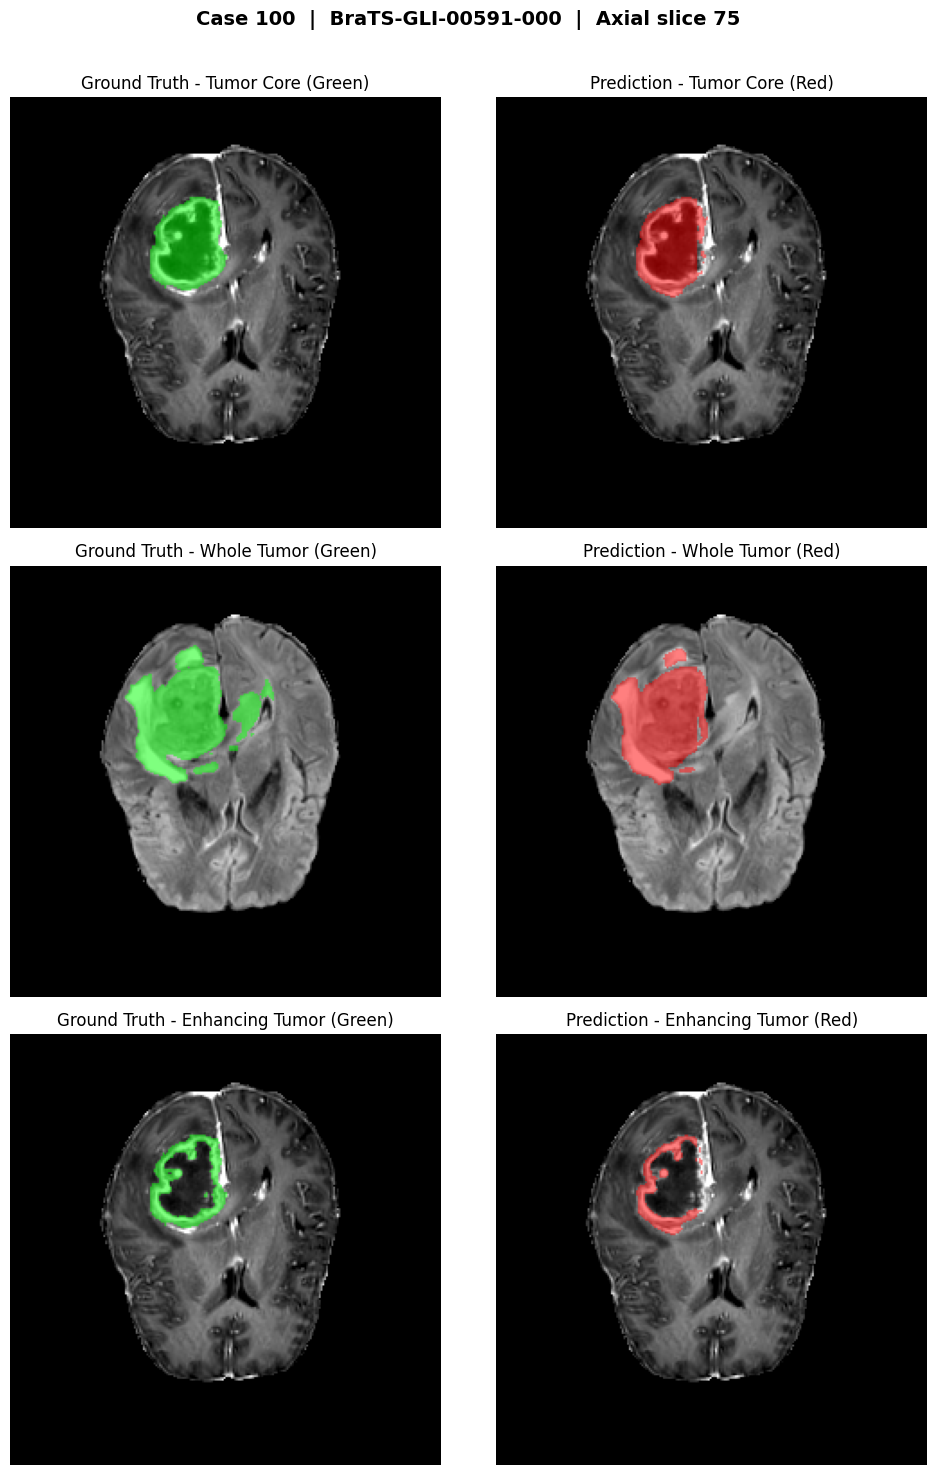

In [17]:
import os
import json
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
import nibabel.processing

def visualize_case_simple(case_number, slice_number,
                   pred_dir=PRED_SAVE_DIR,
                   data_dir=data_dir,
                   json_list=json_list,
                   fold=fold):
    """
    Visualize a specific case and slice with a simple side-by-side
    Ground Truth vs. Prediction comparison.
    """

    # ------------------------------------------------------------------ #
    # 1. Resolve file paths from JSON                                    #
    # ------------------------------------------------------------------ #
    with open(json_list) as f:
        json_data = json.load(f)["training"]

    val_files = [d for d in json_data if "fold" in d and d["fold"] == fold]

    if case_number < 1 or case_number > len(val_files):
        print(f"case_number must be between 1 and {len(val_files)}.")
        return

    entry     = val_files[case_number - 1]
    raw_paths = [os.path.join(data_dir, x) for x in entry["image"]]

    # Reorder channels exactly as get_official_val_loader does
    t1c   = next((p for p in raw_paths if 't1c' in p.lower() or 't1gd' in p.lower()), raw_paths[0])
    flair = next((p for p in raw_paths if 't2f' in p.lower()), raw_paths[3])
    label_path = os.path.join(data_dir, entry["label"])

    # Derive case stem (strip modality suffix)
    case_stem = os.path.basename(t1c).replace(".nii.gz", "").replace(".nii", "")
    for suffix in ["-t1c", "-t1n", "-t2w", "-t2f", "_t1c", "_t1n", "_t2w", "_t2f"]:
        case_stem = case_stem.replace(suffix, "")

    # ------------------------------------------------------------------ #
    # 2. Find saved prediction files                                     #
    # ------------------------------------------------------------------ #
    mask_path_full = os.path.join(pred_dir, f"{case_stem}_pred_mask.nii.gz")

    if not os.path.exists(mask_path_full):
        candidates = [f for f in os.listdir(pred_dir) if case_stem in f and "_pred_mask" in f]
        if not candidates:
            print(f"No prediction mask found for case stem '{case_stem}' in {pred_dir}.")
            return
        mask_path_full = os.path.join(pred_dir, candidates[0])



    # ------------------------------------------------------------------ #
    # 3. Load volumes and ALIGN them                                     #
    # ------------------------------------------------------------------ #
    # Load NIfTI objects
    t1c_nii   = nib.load(t1c)
    flair_nii = nib.load(flair)
    label_nii = nib.load(label_path)
    pred_nii  = nib.load(mask_path_full)

    # Get raw data for the background and ground truth
    img_t1c   = t1c_nii.get_fdata()
    img_flair = flair_nii.get_fdata()
    gt_label  = label_nii.get_fdata()

    # FIX 1: Align the prediction array to the T1c affine space
    # Because pred_mask is 4D (H, W, D, 3), we resample channel by channel
    pred_mask_raw = pred_nii.get_fdata()
    pred_mask = np.zeros_like(pred_mask_raw)

    for i in range(3):
        # Extract single channel as a 3D NIfTI
        channel_img = nib.Nifti1Image(pred_mask_raw[..., i], pred_nii.affine)
        # Resample to T1c space (order=0 means nearest neighbor, required for masks!)
        resampled_img = nibabel.processing.resample_from_to(channel_img, t1c_nii, order=0)
        pred_mask[..., i] = resampled_img.get_fdata()

    # FIX 2: Handle labels 1, 2, and 3 (instead of 4)
    if gt_label.ndim == 3:
        # Assuming 1=Necrotic/Non-enhancing, 2=Edema, 3=Enhancing Tumor
        gt_tc = ((gt_label == 1) | (gt_label == 3)).astype(np.uint8)
        gt_wt = ((gt_label == 1) | (gt_label == 2) | (gt_label == 3)).astype(np.uint8)
        gt_et = (gt_label == 3).astype(np.uint8)
    else:
        gt_tc, gt_wt, gt_et = gt_label[..., 0], gt_label[..., 1], gt_label[..., 2]

    pred_tc = pred_mask[..., 0]
    pred_wt = pred_mask[..., 1]
    pred_et = pred_mask[..., 2]

    n_slices = img_t1c.shape[2]
    if slice_number < 0 or slice_number >= n_slices:
        print(f"slice_number must be between 0 and {n_slices - 1}.")
        return

    sl = slice_number
    # ------------------------------------------------------------------ #
    # 4. Helpers for simpler visualization                               #
    # ------------------------------------------------------------------ #
    def norm(vol):
        sl_img = vol[:, :, sl]
        if sl_img.max() > 0:
            vmin, vmax = np.percentile(sl_img[sl_img > 0], [1, 99])
        else:
            vmin, vmax = 0, 1
        return np.clip((sl_img - vmin) / (vmax - vmin + 1e-8), 0, 1)

    def apply_simple_mask(bg, mask_sl, color):
        """Applies a solid color mask over a grayscale background."""
        rgb = np.stack([bg, bg, bg], axis=-1)
        m = mask_sl.astype(bool)
        alpha = 0.5 # 50% transparency
        for i in range(3):
            rgb[m, i] = rgb[m, i] * (1 - alpha) + color[i] * alpha
        return rgb

    t1c_sl   = norm(img_t1c)
    flair_sl = norm(img_flair)

    # Define colors: Green for Ground Truth, Red for Prediction
    gt_color   = [0, 1, 0]
    pred_color = [1, 0, 0]

    # ------------------------------------------------------------------ #
    # 5. Plot Side-by-Side                                               #
    # ------------------------------------------------------------------ #
    fig, axes = plt.subplots(3, 2, figsize=(10, 15))
    fig.suptitle(f"Case {case_number}  |  {case_stem}  |  Axial slice {sl}", fontsize=14, fontweight="bold")

    # Row 1: Tumor Core (TC)
    axes[0, 0].imshow(apply_simple_mask(t1c_sl.T, gt_tc[:, :, sl].T, gt_color), origin="lower")
    axes[0, 0].set_title("Ground Truth - Tumor Core (Green)")
    axes[0, 1].imshow(apply_simple_mask(t1c_sl.T, pred_tc[:, :, sl].T, pred_color), origin="lower")
    axes[0, 1].set_title("Prediction - Tumor Core (Red)")

    # Row 2: Whole Tumor (WT)
    axes[1, 0].imshow(apply_simple_mask(flair_sl.T, gt_wt[:, :, sl].T, gt_color), origin="lower")
    axes[1, 0].set_title("Ground Truth - Whole Tumor (Green)")
    axes[1, 1].imshow(apply_simple_mask(flair_sl.T, pred_wt[:, :, sl].T, pred_color), origin="lower")
    axes[1, 1].set_title("Prediction - Whole Tumor (Red)")

    # Row 3: Enhancing Tumor (ET)
    axes[2, 0].imshow(apply_simple_mask(t1c_sl.T, gt_et[:, :, sl].T, gt_color), origin="lower")
    axes[2, 0].set_title("Ground Truth - Enhancing Tumor (Green)")
    axes[2, 1].imshow(apply_simple_mask(t1c_sl.T, pred_et[:, :, sl].T, pred_color), origin="lower")
    axes[2, 1].set_title("Prediction - Enhancing Tumor (Red)")

    for ax in axes.flat:
        ax.axis("off")

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

# --- Example usage ---
visualize_case_simple(case_number=100, slice_number=75)